In [7]:
import pandas as pd
import numpy as np
import stockfish as st

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [36]:
df = pd.read_csv("data.csv")
df.head(5)

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,...,success_prob_blitz_1150,success_prob_blitz_1250,success_prob_blitz_1350,success_prob_blitz_1450,success_prob_blitz_1550,success_prob_blitz_1650,success_prob_blitz_1750,success_prob_blitz_1850,success_prob_blitz_1950,success_prob_blitz_2050
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1902,76,95,7226,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN,...,0.218818,0.209653,0.186691,0.164491,0.152678,0.140435,0.136796,0.129520,0.119234,0.117752
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1512,74,96,29629,advantage endgame short,https://lichess.org/F8M8OS71#53,NaN,...,0.034210,0.028367,0.022817,0.018677,0.015565,0.012677,0.009887,0.008078,0.006526,0.004738
2,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1300,75,90,666,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN,...,0.692399,0.689112,0.706355,0.714826,0.720929,0.719589,0.721771,0.710567,0.719568,0.685810
3,0009B,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1078,74,87,573,advantage middlegame short,https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...,...,0.673641,0.676497,0.679858,0.681578,0.672302,0.679798,0.660224,0.642372,0.629270,0.636599
4,000VW,r4r2/1p3pkp/p5p1/3R1N1Q/3P4/8/P1q2P2/3R2K1 b -...,g6f5 d5c5 c2e4 h5g5 g7h8 g5f6,2877,100,91,154,crushing endgame long,https://lichess.org/e9AY2m5j/black#50,NaN,...,0.000228,0.000214,0.000193,0.000182,0.000186,0.000168,0.000154,0.000150,0.000121,0.000122


In [9]:
df.columns

Index(['PuzzleId', 'FEN', 'Moves', 'Rating', 'RatingDeviation', 'Popularity',
       'NbPlays', 'Themes', 'GameUrl', 'OpeningTags',
       'success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050'],
      dtype='str')

# 0. Аналитический способ
---
Идея этого блока состоит в том, что рейтинг по ELO-системе при достаточном числе итераций будет гарантировать вероятность 0.5 решение игроком задачи своего рейтинга.
В таком случае статистическая информация для задач должна быть достаточной для предсказания рейтинга.

Так как тогда все эти вероятности решения - дискретизация логистической кривой

$$P(r) = \frac{1}{1+\exp{-k(r-d)}}$$

In [10]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

"""
P.S. У этой функции смешной интерфейс, чтобы потом сделать мини-трейн для обучаемого объединения 
результатов для статистики блиц и рапид вместо простого усреднения

"""


class SigmoidPuzzleRegressor:
    def __init__(self):
        self.rating_levels = np.array(
            [1050, 1150, 1250, 1350, 1450, 1550, 1650, 1750, 1850, 1950, 2050],
            dtype=float
        )

    @staticmethod
    def sigmoid(x, r0, k):
        return 1.0 / (1.0 + np.exp(-k * (x - r0)))

    def fit_sigmoid_from_probs(self, probs):
        x = self.rating_levels
        y = np.asarray(probs, dtype=float)

        y = np.clip(y, 1e-6, 1 - 1e-6)

        if y.min() <= 0.5 <= y.max():
            r0_init = np.interp(0.5, y, x)
        else:
            r0_init = x.mean()

        k_init = 0.01

        try:
            popt, _ = curve_fit(
                self.sigmoid,
                x,
                y,
                p0=[r0_init, k_init],
                bounds=([800.0, 1e-5], [3000.0, 1.0]),
                maxfev=10000
            )
            r0, k = popt
            y_fit = self.sigmoid(x, r0, k)
            mse = np.mean((y - y_fit) ** 2)
            return float(r0), float(k), float(mse)
        except Exception:
            return np.nan, np.nan, np.inf

    def predict_one(self, probs):
        probs = np.asarray(probs, dtype=float)

        rapid_probs = probs[:11]
        blitz_probs = probs[11:]

        rapid_r0, rapid_k, rapid_mse = self.fit_sigmoid_from_probs(rapid_probs)
        blitz_r0, blitz_k, blitz_mse = self.fit_sigmoid_from_probs(blitz_probs)

        if np.isfinite(rapid_r0) and np.isfinite(blitz_r0):
            w_rapid = 1.0 / (rapid_mse + 1e-8)
            w_blitz = 1.0 / (blitz_mse + 1e-8)
            rating_pred = (w_rapid * rapid_r0 + w_blitz * blitz_r0) / (w_rapid + w_blitz)
        elif np.isfinite(rapid_r0):
            rating_pred = rapid_r0
        elif np.isfinite(blitz_r0):
            rating_pred = blitz_r0
        else:
            rating_pred = np.nan

        return float(rating_pred)

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = [self.predict_one(row) for row in X]
        return np.array(preds, dtype=float)

In [28]:
def show_sigmoid(row):

    ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

    rapid_cols = [
    'success_prob_rapid_1050','success_prob_rapid_1150','success_prob_rapid_1250',
    'success_prob_rapid_1350','success_prob_rapid_1450','success_prob_rapid_1550',
    'success_prob_rapid_1650','success_prob_rapid_1750','success_prob_rapid_1850',
    'success_prob_rapid_1950','success_prob_rapid_2050'
    ]

    probs = row[rapid_cols].values

    def sigmoid(x, r0, k):
        return 1/(1+np.exp(-k*(x-r0)))

    y = np.clip(probs, 1e-6, 1-1e-6)

    r0_init = np.interp(0.5, y, ratings) if (y.min()<=0.5<=y.max()) else ratings.mean()

    plt.figure(figsize=(7,4))

    plt.scatter(ratings,probs,label="data",s=60)

    try:
        params, _ = curve_fit(
            sigmoid,
            ratings,
            y,
            p0=[r0_init,0.01],
            maxfev=5000
        )

        r0,k = params

        x_dense = np.linspace(1000,2100,400)
        y_fit = sigmoid(x_dense,r0,k)


        plt.plot(x_dense,y_fit,label="sigmoid fit")
    except:
        pass

    plt.xlabel("Player rating")
    plt.ylabel("Success probability")
    plt.title(f"Task rating: {row['Rating']}")

    plt.legend()
    plt.grid(True)

    plt.show()

31


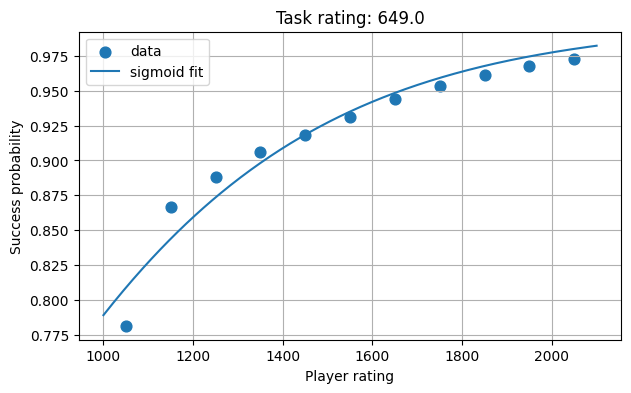

27


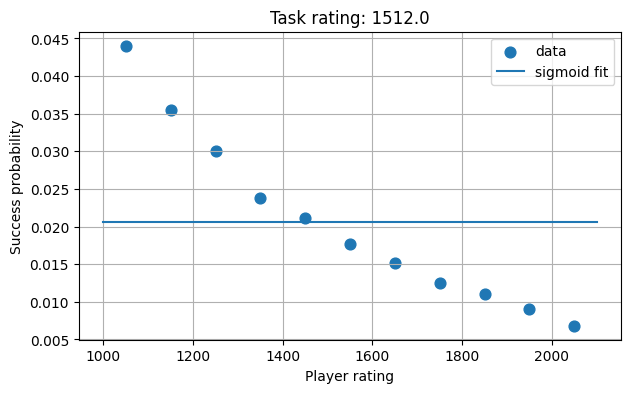

0


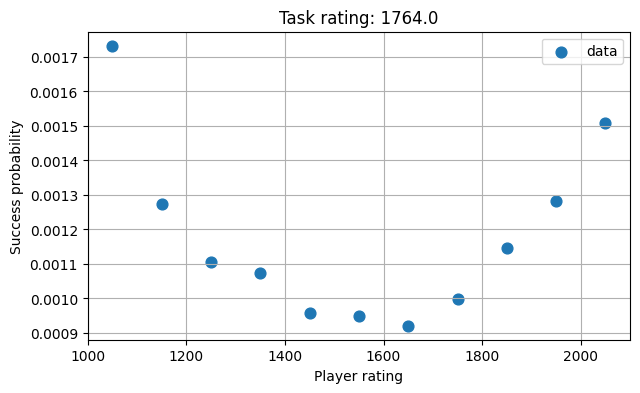

22


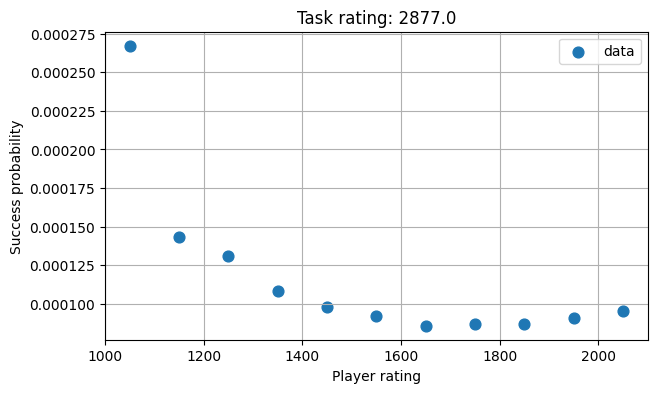

In [35]:
from random import randint
ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

rapid_cols = [
    'success_prob_rapid_1050','success_prob_rapid_1150','success_prob_rapid_1250',
    'success_prob_rapid_1350','success_prob_rapid_1450','success_prob_rapid_1550',
    'success_prob_rapid_1650','success_prob_rapid_1750','success_prob_rapid_1850',
    'success_prob_rapid_1950','success_prob_rapid_2050','Rating'
    ]
dfcut = df[rapid_cols]
for i in [38, 1, 83, 4]:
    x = randint(0, 100)
    row = dfcut.iloc[i]
    print(x)
    show_sigmoid(row)


In [12]:
feature_cols = [
    'success_prob_rapid_1050', 'success_prob_rapid_1150',
    'success_prob_rapid_1250', 'success_prob_rapid_1350',
    'success_prob_rapid_1450', 'success_prob_rapid_1550',
    'success_prob_rapid_1650', 'success_prob_rapid_1750',
    'success_prob_rapid_1850', 'success_prob_rapid_1950',
    'success_prob_rapid_2050',
    'success_prob_blitz_1050', 'success_prob_blitz_1150',
    'success_prob_blitz_1250', 'success_prob_blitz_1350',
    'success_prob_blitz_1450', 'success_prob_blitz_1550',
    'success_prob_blitz_1650', 'success_prob_blitz_1750',
    'success_prob_blitz_1850', 'success_prob_blitz_1950',
    'success_prob_blitz_2050'
]

df_small = df.sample(n=100_000, random_state=42)

X = df_small[feature_cols]
y = df_small['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = SigmoidPuzzleRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mask = ~np.isnan(y_pred)
y_test_valid = y_test.iloc[mask]
y_pred_valid = y_pred[mask]

print("R2:", r2_score(y_test_valid, y_pred_valid))
print("MAE:", mean_absolute_error(y_test_valid, y_pred_valid))
print("RMSE:", np.sqrt(mean_squared_error(y_test_valid, y_pred_valid)))

R2: -2.195437210813053
MAE: 785.2966871120186
RMSE: 969.8299976593504


# 1. Линейные модели
---


In [14]:
dfreg = df[['Rating',
       'success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]
print("full size", dfreg.shape)
dfreg.dropna()
print("size without nans", dfreg.shape)


full size (4557000, 23)
size without nans (4557000, 23)


Посмотрим, насколько хорошо видна корреляция между предсказанными движком вероятностями 

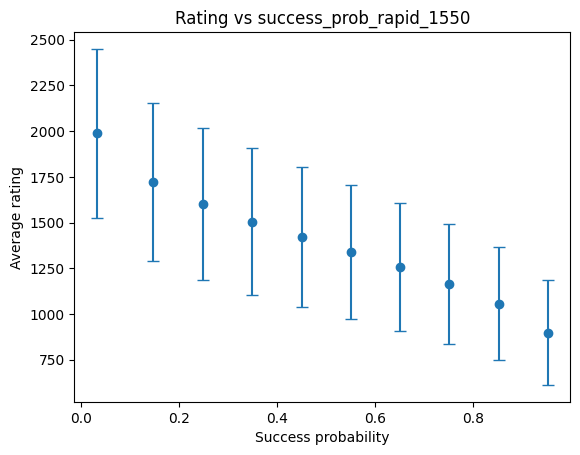

In [15]:
prob_col = 'success_prob_rapid_1550'
n_bins = 10
dfreg['prob_bin'] = pd.cut(dfreg[prob_col], bins=n_bins)

stats = dfreg.groupby('prob_bin').agg(
    prob_mean=(prob_col, 'mean'),
    rating_mean=('Rating', 'mean'),
    rating_std=('Rating', 'std'),
    count=('Rating', 'size')
).reset_index()

plt.errorbar(
    stats['prob_mean'],
    stats['rating_mean'],
    yerr=stats['rating_std'],
    fmt='o',
    capsize=4
)

plt.xlabel("Success probability")
plt.ylabel("Average rating")
plt.title(f"Rating vs {prob_col}")

plt.show()

Перейдём к модели

In [16]:
X = df[['success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]

y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=100000)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Best alpha:", model.named_steps['lassocv'].alpha_)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best alpha: 0.3808444241789319
R2: 0.4931134718352346
MAE: 309.42495625637827
RMSE: 387.3266323637934


In [18]:
coef = model.named_steps['lassocv'].coef_

coef = model.named_steps['lassocv'].coef_
for feature, weight in zip(X.columns, coef):
    print(feature, weight)

success_prob_rapid_1050 -0.0
success_prob_rapid_1150 -226.3787518760727
success_prob_rapid_1250 -0.0
success_prob_rapid_1350 -0.0
success_prob_rapid_1450 -46.11950556755898
success_prob_rapid_1550 -0.0
success_prob_rapid_1650 0.0
success_prob_rapid_1750 -0.0
success_prob_rapid_1850 0.0
success_prob_rapid_1950 -0.0
success_prob_rapid_2050 -30.157258659582414
success_prob_blitz_1050 -144.34280691834618
success_prob_blitz_1150 -0.0
success_prob_blitz_1250 0.0
success_prob_blitz_1350 0.0
success_prob_blitz_1450 0.0
success_prob_blitz_1550 138.4177040074611
success_prob_blitz_1650 -0.0
success_prob_blitz_1750 0.0
success_prob_blitz_1850 0.0
success_prob_blitz_1950 0.0
success_prob_blitz_2050 -81.05635115017259


Для лучшего линейного результата воспользуемся __Ridge__

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df[['success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]

y = df['Rating']

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 50))
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Best alpha:", model.named_steps['ridgecv'].alpha_)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best alpha: 0.0517947467923121
R2: 0.5087312878550785
MAE: 303.72139159624925
RMSE: 381.31293545056934


О да, __Ridge__ лучше целых на 6 RMSE

# Forests